**MES IMPORTS**

In [38]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from xgboost import XGBRegressor


**ÉTAPE 1 — Charger et explorer le dataset**

In [39]:
path='PRSA_data.csv'
df=pd.read_csv(path)
print(df.head())
print("***********************")
print(df.info())
print("***********************")


   No  year  month  day  hour  pm2.5  DEWP  TEMP    PRES cbwd    Iws  Is  Ir
0   1  2010      1    1     0    NaN   -21 -11.0  1021.0   NW   1.79   0   0
1   2  2010      1    1     1    NaN   -21 -12.0  1020.0   NW   4.92   0   0
2   3  2010      1    1     2    NaN   -21 -11.0  1019.0   NW   6.71   0   0
3   4  2010      1    1     3    NaN   -21 -14.0  1019.0   NW   9.84   0   0
4   5  2010      1    1     4    NaN   -20 -12.0  1018.0   NW  12.97   0   0
***********************
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43824 entries, 0 to 43823
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   No      43824 non-null  int64  
 1   year    43824 non-null  int64  
 2   month   43824 non-null  int64  
 3   day     43824 non-null  int64  
 4   hour    43824 non-null  int64  
 5   pm2.5   41757 non-null  float64
 6   DEWP    43824 non-null  int64  
 7   TEMP    43824 non-null  float64
 8   PRES    43824 non-null  float6

In [40]:
print(df.describe())

                 No          year         month           day          hour  \
count  43824.000000  43824.000000  43824.000000  43824.000000  43824.000000   
mean   21912.500000   2012.000000      6.523549     15.727820     11.500000   
std    12651.043435      1.413842      3.448572      8.799425      6.922266   
min        1.000000   2010.000000      1.000000      1.000000      0.000000   
25%    10956.750000   2011.000000      4.000000      8.000000      5.750000   
50%    21912.500000   2012.000000      7.000000     16.000000     11.500000   
75%    32868.250000   2013.000000     10.000000     23.000000     17.250000   
max    43824.000000   2014.000000     12.000000     31.000000     23.000000   

              pm2.5          DEWP          TEMP          PRES           Iws  \
count  41757.000000  43824.000000  43824.000000  43824.000000  43824.000000   
mean      98.613215      1.817246     12.448521   1016.447654     23.889140   
std       92.050387     14.433440     12.198613    


**ÉTAPE 2 — Comprendre les données manquantes**

In [41]:
df.isnull().sum()

No          0
year        0
month       0
day         0
hour        0
pm2.5    2067
DEWP        0
TEMP        0
PRES        0
cbwd        0
Iws         0
Is          0
Ir          0
dtype: int64

In [42]:
df['Ir'].value_counts()

Ir
0     42016
1       529
2       316
3       214
4       136
5       113
6        88
7        74
8        55
9        45
10       37
11       32
12       26
13       21
14       18
15       12
17       10
18       10
16        9
19        9
20        8
22        8
21        7
23        7
24        3
25        3
26        2
27        2
28        2
29        2
30        2
31        2
32        2
33        1
34        1
35        1
36        1
Name: count, dtype: int64

**ÉTAPE 3 — Nettoyage intelligent**

In [43]:
df=df.drop("No",axis=1)
df

,year,month,day,hour,pm2.5,DEWP,TEMP,PRES,cbwd,Iws,Is,Ir
0,2010,1,1,0,NaN,-21,-11.0,1021.0,NW,1.79,0,0
1,2010,1,1,1,NaN,-21,-12.0,1020.0,NW,4.92,0,0
2,2010,1,1,2,NaN,-21,-11.0,1019.0,NW,6.71,0,0
3,2010,1,1,3,NaN,-21,-14.0,1019.0,NW,9.84,0,0
4,2010,1,1,4,NaN,-20,-12.0,1018.0,NW,12.97,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
43819,2014,12,31,19,8.0,-23,-2.0,1034.0,NW,231.97,0,0
43820,2014,12,31,20,10.0,-22,-3.0,1034.0,NW,237.78,0,0
43821,2014,12,31,21,10.0,-22,-3.0,1034.0,NW,242.70,0,0
43822,2014,12,31,22,8.0,-22,-4.0,1034.0,NW,246.72,0,0


In [44]:
print("Gestion des valeurs manquantes")
df["pm2.5"] = df["pm2.5"].fillna(method="ffill")
df["pm2.5"] = df["pm2.5"].fillna(method="bfill")

df.isnull().sum()

Gestion des valeurs manquantes


C:\Users\user\AppData\Local\Temp\ipykernel_13860\3582256881.py:2: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df["pm2.5"] = df["pm2.5"].fillna(method="ffill")
C:\Users\user\AppData\Local\Temp\ipykernel_13860\3582256881.py:3: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df["pm2.5"] = df["pm2.5"].fillna(method="bfill")


year     0
month    0
day      0
hour     0
pm2.5    0
DEWP     0
TEMP     0
PRES     0
cbwd     0
Iws      0
Is       0
Ir       0
dtype: int64

In [45]:
df['cbwd'].value_counts()

cbwd
SE    15290
NW    14150
cv     9387
NE     4997
Name: count, dtype: int64

In [46]:
print("creation d'une colonne date")
df['date']=pd.to_datetime(df[['year','month','day','hour']])
df = df.sort_values("date")
df.head()

creation d'une colonne date


,year,month,day,hour,pm2.5,DEWP,TEMP,PRES,cbwd,Iws,Is,Ir,date
0,2010,1,1,0,129.0,-21,-11.0,1021.0,NW,1.79,0,0,2010-01-01 00:00:00
1,2010,1,1,1,129.0,-21,-12.0,1020.0,NW,4.92,0,0,2010-01-01 01:00:00
2,2010,1,1,2,129.0,-21,-11.0,1019.0,NW,6.71,0,0,2010-01-01 02:00:00
3,2010,1,1,3,129.0,-21,-14.0,1019.0,NW,9.84,0,0,2010-01-01 03:00:00
4,2010,1,1,4,129.0,-20,-12.0,1018.0,NW,12.97,0,0,2010-01-01 04:00:00


In [47]:
print("creation de la variable cible")
df["target"]=df["pm2.5"].shift(-1)
df.head()

creation de la variable cible


,year,month,day,hour,pm2.5,DEWP,TEMP,PRES,cbwd,Iws,Is,Ir,date,target
0,2010,1,1,0,129.0,-21,-11.0,1021.0,NW,1.79,0,0,2010-01-01 00:00:00,129.0
1,2010,1,1,1,129.0,-21,-12.0,1020.0,NW,4.92,0,0,2010-01-01 01:00:00,129.0
2,2010,1,1,2,129.0,-21,-11.0,1019.0,NW,6.71,0,0,2010-01-01 02:00:00,129.0
3,2010,1,1,3,129.0,-21,-14.0,1019.0,NW,9.84,0,0,2010-01-01 03:00:00,129.0
4,2010,1,1,4,129.0,-20,-12.0,1018.0,NW,12.97,0,0,2010-01-01 04:00:00,129.0


*Variables temporelles*

In [48]:
df["day_of_week"] = df["date"].dt.dayofweek
df

,year,month,day,hour,pm2.5,DEWP,TEMP,PRES,cbwd,Iws,Is,Ir,date,target,day_of_week
0,2010,1,1,0,129.0,-21,-11.0,1021.0,NW,1.79,0,0,2010-01-01 00:00:00,129.0,4
1,2010,1,1,1,129.0,-21,-12.0,1020.0,NW,4.92,0,0,2010-01-01 01:00:00,129.0,4
2,2010,1,1,2,129.0,-21,-11.0,1019.0,NW,6.71,0,0,2010-01-01 02:00:00,129.0,4
3,2010,1,1,3,129.0,-21,-14.0,1019.0,NW,9.84,0,0,2010-01-01 03:00:00,129.0,4
4,2010,1,1,4,129.0,-20,-12.0,1018.0,NW,12.97,0,0,2010-01-01 04:00:00,129.0,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43819,2014,12,31,19,8.0,-23,-2.0,1034.0,NW,231.97,0,0,2014-12-31 19:00:00,10.0,2
43820,2014,12,31,20,10.0,-22,-3.0,1034.0,NW,237.78,0,0,2014-12-31 20:00:00,10.0,2
43821,2014,12,31,21,10.0,-22,-3.0,1034.0,NW,242.70,0,0,2014-12-31 21:00:00,8.0,2
43822,2014,12,31,22,8.0,-22,-4.0,1034.0,NW,246.72,0,0,2014-12-31 22:00:00,12.0,2


In [49]:
print("la moyenne glissante")
df["pm25_mean_3"] = df["pm2.5"].rolling(3).mean()
df["rolling_6"] = df["pm2.5"].rolling(6).mean()
df["rolling_12"] = df["pm2.5"].rolling(12).mean()
print("pollution des heures precedents")
df["pm25_t-1"] = df["pm2.5"].shift(1)
df["pm25_t-2"] = df["pm2.5"].shift(2)
df["pm25_t-3"] = df["pm2.5"].shift(3)
df

la moyenne glissante
pollution des heures precedents


,year,month,day,hour,pm2.5,DEWP,TEMP,PRES,cbwd,Iws,...,Ir,date,target,day_of_week,pm25_mean_3,rolling_6,rolling_12,pm25_t-1,pm25_t-2,pm25_t-3
0,2010,1,1,0,129.0,-21,-11.0,1021.0,NW,1.79,...,0,2010-01-01 00:00:00,129.0,4,NaN,NaN,NaN,NaN,NaN,NaN
1,2010,1,1,1,129.0,-21,-12.0,1020.0,NW,4.92,...,0,2010-01-01 01:00:00,129.0,4,NaN,NaN,NaN,129.0,NaN,NaN
2,2010,1,1,2,129.0,-21,-11.0,1019.0,NW,6.71,...,0,2010-01-01 02:00:00,129.0,4,129.000000,NaN,NaN,129.0,129.0,NaN
3,2010,1,1,3,129.0,-21,-14.0,1019.0,NW,9.84,...,0,2010-01-01 03:00:00,129.0,4,129.000000,NaN,NaN,129.0,129.0,129.0
4,2010,1,1,4,129.0,-20,-12.0,1018.0,NW,12.97,...,0,2010-01-01 04:00:00,129.0,4,129.000000,NaN,NaN,129.0,129.0,129.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43819,2014,12,31,19,8.0,-23,-2.0,1034.0,NW,231.97,...,0,2014-12-31 19:00:00,10.0,2,9.000000,9.166667,9.833333,10.0,9.0,8.0
43820,2014,12,31,20,10.0,-22,-3.0,1034.0,NW,237.78,...,0,2014-12-31 20:00:00,10.0,2,9.333333,9.333333,10.000000,8.0,10.0,9.0
43821,2014,12,31,21,10.0,-22,-3.0,1034.0,NW,242.70,...,0,2014-12-31 21:00:00,8.0,2,9.333333,9.166667,10.166667,10.0,8.0,10.0
43822,2014,12,31,22,8.0,-22,-4.0,1034.0,NW,246.72,...,0,2014-12-31 22:00:00,12.0,2,9.333333,9.166667,10.250000,10.0,10.0,8.0


In [50]:
df = df.dropna()
df.isnull().sum()

year           0
month          0
day            0
hour           0
pm2.5          0
DEWP           0
TEMP           0
PRES           0
cbwd           0
Iws            0
Is             0
Ir             0
date           0
target         0
day_of_week    0
pm25_mean_3    0
rolling_6      0
rolling_12     0
pm25_t-1       0
pm25_t-2       0
pm25_t-3       0
dtype: int64

In [51]:
df = pd.get_dummies(df, columns=["cbwd"])

In [52]:
df

,year,month,day,hour,pm2.5,DEWP,TEMP,PRES,Iws,Is,...,pm25_mean_3,rolling_6,rolling_12,pm25_t-1,pm25_t-2,pm25_t-3,cbwd_NE,cbwd_NW,cbwd_SE,cbwd_cv
11,2010,1,1,11,129.0,-18,-5.0,1017.0,34.43,0,...,129.000000,129.000000,129.000000,129.0,129.0,129.0,False,True,False,False
12,2010,1,1,12,129.0,-19,-5.0,1015.0,37.56,0,...,129.000000,129.000000,129.000000,129.0,129.0,129.0,False,True,False,False
13,2010,1,1,13,129.0,-18,-3.0,1015.0,40.69,0,...,129.000000,129.000000,129.000000,129.0,129.0,129.0,False,True,False,False
14,2010,1,1,14,129.0,-18,-2.0,1014.0,43.82,0,...,129.000000,129.000000,129.000000,129.0,129.0,129.0,False,True,False,False
15,2010,1,1,15,129.0,-18,-1.0,1014.0,0.89,0,...,129.000000,129.000000,129.000000,129.0,129.0,129.0,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43818,2014,12,31,18,10.0,-22,-2.0,1033.0,226.16,0,...,9.000000,9.666667,9.833333,9.0,8.0,11.0,False,True,False,False
43819,2014,12,31,19,8.0,-23,-2.0,1034.0,231.97,0,...,9.000000,9.166667,9.833333,10.0,9.0,8.0,False,True,False,False
43820,2014,12,31,20,10.0,-22,-3.0,1034.0,237.78,0,...,9.333333,9.333333,10.000000,8.0,10.0,9.0,False,True,False,False
43821,2014,12,31,21,10.0,-22,-3.0,1034.0,242.70,0,...,9.333333,9.166667,10.166667,10.0,8.0,10.0,False,True,False,False


In [53]:
df.dropna()


,year,month,day,hour,pm2.5,DEWP,TEMP,PRES,Iws,Is,...,pm25_mean_3,rolling_6,rolling_12,pm25_t-1,pm25_t-2,pm25_t-3,cbwd_NE,cbwd_NW,cbwd_SE,cbwd_cv
11,2010,1,1,11,129.0,-18,-5.0,1017.0,34.43,0,...,129.000000,129.000000,129.000000,129.0,129.0,129.0,False,True,False,False
12,2010,1,1,12,129.0,-19,-5.0,1015.0,37.56,0,...,129.000000,129.000000,129.000000,129.0,129.0,129.0,False,True,False,False
13,2010,1,1,13,129.0,-18,-3.0,1015.0,40.69,0,...,129.000000,129.000000,129.000000,129.0,129.0,129.0,False,True,False,False
14,2010,1,1,14,129.0,-18,-2.0,1014.0,43.82,0,...,129.000000,129.000000,129.000000,129.0,129.0,129.0,False,True,False,False
15,2010,1,1,15,129.0,-18,-1.0,1014.0,0.89,0,...,129.000000,129.000000,129.000000,129.0,129.0,129.0,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43818,2014,12,31,18,10.0,-22,-2.0,1033.0,226.16,0,...,9.000000,9.666667,9.833333,9.0,8.0,11.0,False,True,False,False
43819,2014,12,31,19,8.0,-23,-2.0,1034.0,231.97,0,...,9.000000,9.166667,9.833333,10.0,9.0,8.0,False,True,False,False
43820,2014,12,31,20,10.0,-22,-3.0,1034.0,237.78,0,...,9.333333,9.333333,10.000000,8.0,10.0,9.0,False,True,False,False
43821,2014,12,31,21,10.0,-22,-3.0,1034.0,242.70,0,...,9.333333,9.166667,10.166667,10.0,8.0,10.0,False,True,False,False


In [54]:
df["temp_wind"] = df["TEMP"] * df["Iws"]
df.isna().sum()

year           0
month          0
day            0
hour           0
pm2.5          0
DEWP           0
TEMP           0
PRES           0
Iws            0
Is             0
Ir             0
date           0
target         0
day_of_week    0
pm25_mean_3    0
rolling_6      0
rolling_12     0
pm25_t-1       0
pm25_t-2       0
pm25_t-3       0
cbwd_NE        0
cbwd_NW        0
cbwd_SE        0
cbwd_cv        0
temp_wind      0
dtype: int64

verification correlation


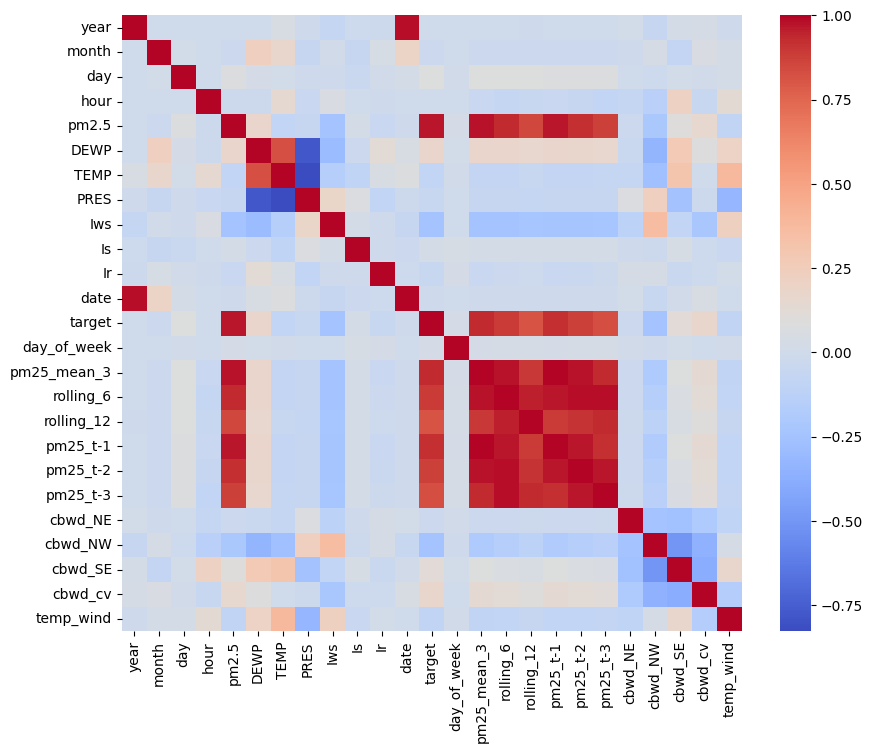

In [55]:
print("verification correlation")
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.show()

**ETAPE PREPARATION ML**

In [56]:
from sklearn.model_selection import train_test_split

X = df.drop(["target","date"], axis=1)
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

**MODELE**

In [57]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(max_depth=10)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

**EVALUATION DU MODELE**

In [58]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, y_pred)
print("MAE :", mae)

MAE : 11.571623060961892


on a eu changer les hyperparametre (max_depth,n_estimators) mais max_depth=10 est meilleur

In [59]:


baseline_pred = np.mean(y_train)

y_pred_baseline = np.full(len(y_test), baseline_pred)

from sklearn.metrics import mean_absolute_error
mae_baseline = mean_absolute_error(y_test, y_pred_baseline)

print("MAE baseline :", mae_baseline)
print("MAE modèle :",11.546726074573849)

MAE baseline : 69.14604719269026
MAE modèle : 11.546726074573849


MAE baseline est superieur a MAE modele donc notre modele a une importance

Visualisations

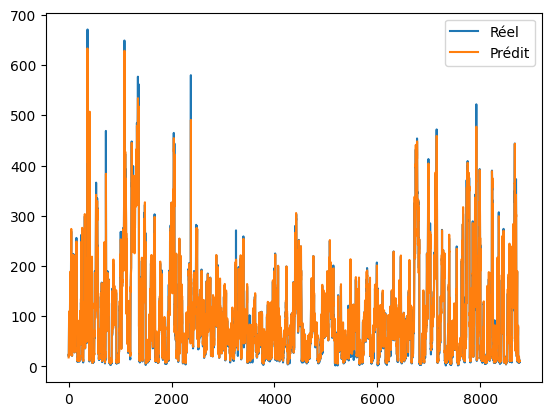

In [60]:
plt.plot(y_test.values, label="Réel")
plt.plot(y_pred, label="Prédit")
plt.legend()
plt.show()

In [61]:
from sklearn.ensemble import GradientBoostingRegressor

model2= GradientBoostingRegressor()
model2.fit(X_train, y_train)

y_pred2 = model2.predict(X_test)
mae2 = mean_absolute_error(y_test, y_pred2)
print("MAE :", mae2)


MAE : 11.642795873799816


le prenier modele est alors le meilleur

**IMPORTANCES DES VARIABLES**

In [62]:
importance = model.feature_importances_
feat_imp = pd.Series(importance, index=X.columns)

print(feat_imp.sort_values(ascending=False))
plt.show()

pm2.5          0.967285
pm25_t-1       0.006201
DEWP           0.004082
pm25_mean_3    0.002605
rolling_12     0.002351
temp_wind      0.002064
pm25_t-2       0.001900
rolling_6      0.001895
pm25_t-3       0.001675
hour           0.001375
Iws            0.001309
TEMP           0.001202
day            0.001120
PRES           0.001106
cbwd_NW        0.001008
Ir             0.000639
month          0.000627
day_of_week    0.000536
year           0.000345
cbwd_SE        0.000306
cbwd_NE        0.000173
cbwd_cv        0.000109
Is             0.000085
dtype: float64


la variable pm2.5 est dominant
revoyons alors nos variables.notre modele est biaise car depend a 92% de la variable pm2.5.

In [63]:
X = df.drop(["target","date","pm2.5","Is"], axis=1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
print("MAE :", mae)

MAE : 13.095478346792937


In [64]:
importance = model.feature_importances_
feat_imp = pd.Series(importance, index=X.columns)

print(feat_imp.sort_values(ascending=False))
plt.show()

pm25_mean_3    0.922128
pm25_t-2       0.036195
pm25_t-1       0.014476
rolling_6      0.005535
DEWP           0.004136
rolling_12     0.002333
pm25_t-3       0.002180
temp_wind      0.002108
hour           0.001973
Iws            0.001469
PRES           0.001296
TEMP           0.001116
day            0.001086
cbwd_NW        0.000856
day_of_week    0.000705
month          0.000637
cbwd_SE        0.000596
Ir             0.000493
year           0.000431
cbwd_NE        0.000151
cbwd_cv        0.000101
dtype: float64


Visualisation des predictions


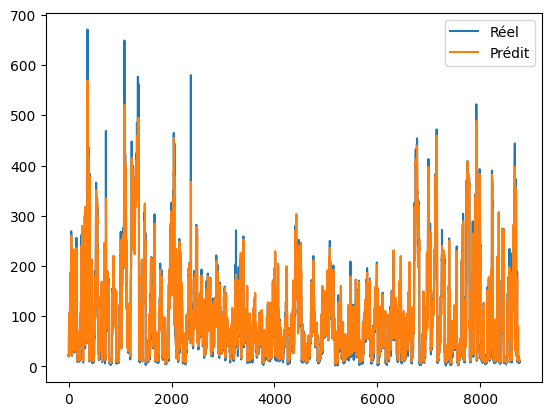

In [65]:
print("Visualisation des predictions")
plt.plot(y_test.values, label="Réel")
plt.plot(y_pred, label="Prédit")
plt.legend()
plt.show()

**ESSAYONS AVEC XGBOOST**

In [66]:
model3 = XGBRegressor(
    n_estimators=400,
    learning_rate=0.02,
    max_depth=9,
    random_state=42
)
model3.fit(X_train, y_train)
y_pred = model3.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
print("MAE :", mae)

MAE : 12.552876954153223


In [67]:
importance = model3.feature_importances_
feat_imp = pd.Series(importance, index=X.columns)

print(feat_imp.sort_values(ascending=False))
plt.show()

pm25_mean_3    0.821862
pm25_t-2       0.035038
cbwd_NW        0.027082
pm25_t-1       0.014566
DEWP           0.010626
temp_wind      0.008160
Ir             0.008106
cbwd_SE        0.007422
Iws            0.006620
day_of_week    0.006589
PRES           0.006524
hour           0.005885
TEMP           0.005686
cbwd_NE        0.005645
pm25_t-3       0.005532
rolling_12     0.005500
rolling_6      0.004702
day            0.004354
cbwd_cv        0.003733
month          0.003614
year           0.002754
dtype: float32


le modele xgboost est le meilleur car on un MAE inferieur par rapport a celui des autres models auparavant,et en plus notre variable x contient des features dont leur importance est realiste scientifiquement.


**SAUVEGARDONS NOTRE MODELE**

In [71]:
import joblib

joblib.dump(model3, "app/xgboost_model.pkl")

['app/xgboost_model.pkl']

In [72]:
print("enregistrons nos features dans un fichier")
features = X.columns.tolist()
print(features)
joblib.dump(features, "app/features.pkl")

enregistrons nos features dans un fichier
['year', 'month', 'day', 'hour', 'DEWP', 'TEMP', 'PRES', 'Iws', 'Ir', 'day_of_week', 'pm25_mean_3', 'rolling_6', 'rolling_12', 'pm25_t-1', 'pm25_t-2', 'pm25_t-3', 'cbwd_NE', 'cbwd_NW', 'cbwd_SE', 'cbwd_cv', 'temp_wind']


['app/features.pkl']

In [73]:
model_loaded = joblib.load("app/xgboost_model.pkl")